In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import urllib.request

urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv',
    'insurance.csv'
)
df = pd.read_csv('insurance.csv')
print("Dataset loaded! Shape:", df.shape)
df.head()

Dataset loaded! Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
# Data cleaning - check missing values
print("Missing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Basic Statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
# Encode categorical columns
le = LabelEncoder()
df_enc = df.copy()
for col in ['sex', 'smoker', 'region']:
    df_enc[col] = le.fit_transform(df_enc[col])

print("Encoding done!")
df_enc.head()

Encoding done!


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


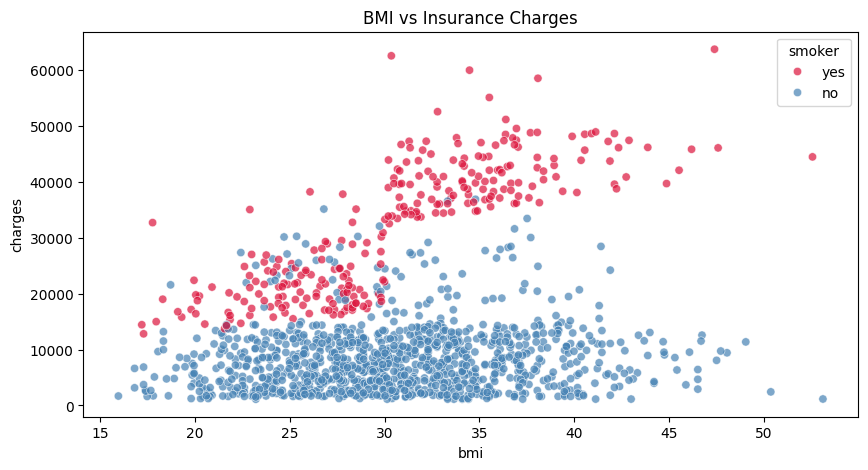

In [4]:
# EDA - BMI vs Charges
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker',
                palette={'yes': 'crimson', 'no': 'steelblue'}, alpha=0.7)
plt.title('BMI vs Insurance Charges')
plt.show()

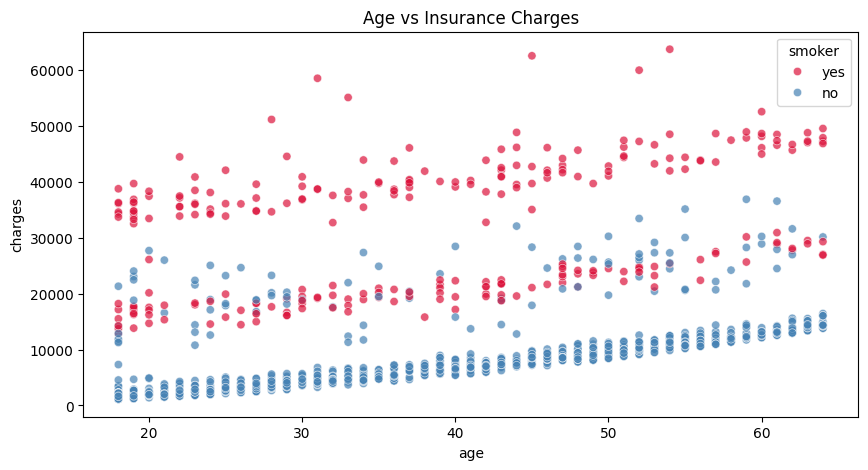

In [5]:
# Age vs Charges
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker',
                palette={'yes': 'crimson', 'no': 'steelblue'}, alpha=0.7)
plt.title('Age vs Insurance Charges')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24068\2602047649.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges',


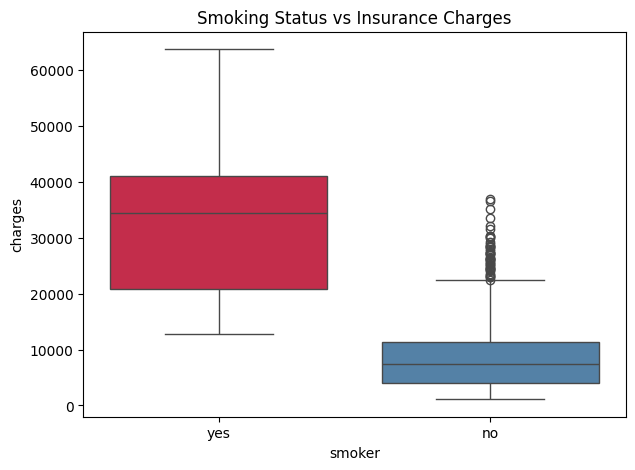

In [6]:
# Smoker vs Charges
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='smoker', y='charges',
            palette={'yes': 'crimson', 'no': 'steelblue'})
plt.title('Smoking Status vs Insurance Charges')
plt.show()

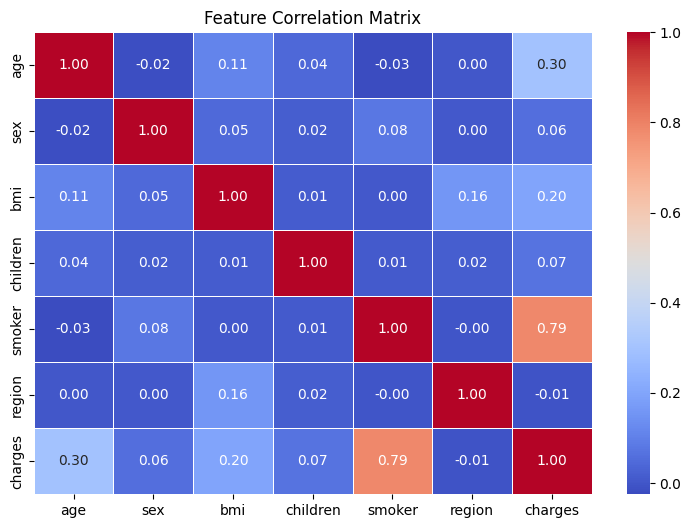

In [7]:
# Correlation Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df_enc.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [8]:
# Train Linear Regression Model
X = df_enc.drop('charges', axis=1)
y = df_enc['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples : {len(X_test)}')
print('Model trained successfully!')

Training samples: 1070
Testing samples : 268
Model trained successfully!


In [9]:
# Evaluate Model
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = model.score(X_test, y_test)

print(f'Mean Absolute Error  (MAE) : ${mae:,.2f}')
print(f'Root Mean Squared Error (RMSE): ${rmse:,.2f}')
print(f'R² Score                      : {r2:.4f}')

Mean Absolute Error  (MAE) : $4,186.51
Root Mean Squared Error (RMSE): $5,799.59
R² Score                      : 0.7833


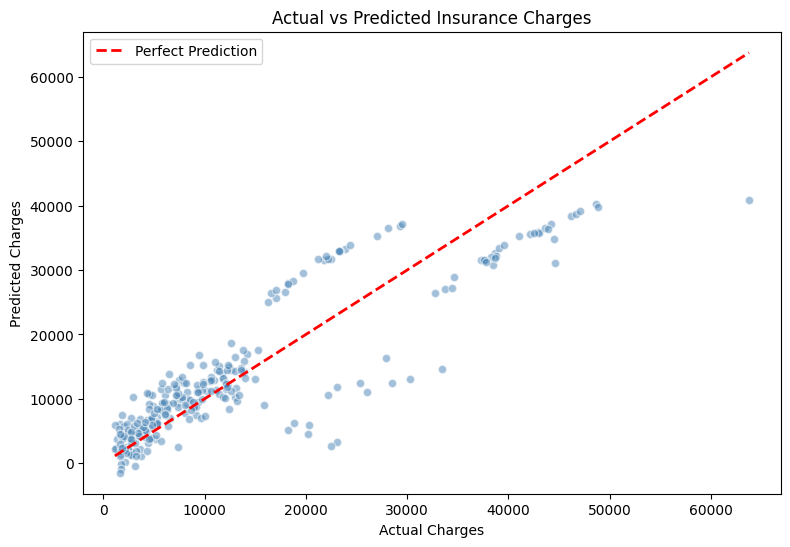

In [10]:
# Actual vs Predicted
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.legend()
plt.show()

## Conclusion

### Key Insights:
- **Smoking** is the most impactful factor — smokers pay 4-5x more in charges (correlation: 0.79)
- **Age** has moderate impact on charges (correlation: 0.30)
- **BMI** also positively affects charges (correlation: 0.20)
- **Sex, region, children** have minimal effect

### Model Performance:
| Metric | Value |
|--------|-------|
| MAE    | $4,186.51 |
| RMSE   | $5,799.59 |
| R²     | 0.7833 |

### Summary:
Linear Regression explains 78% of the variance in insurance charges.
The model performs well for non-smokers but struggles with high-charge smoker cases.
Non-linear models (Random Forest) could improve accuracy further.